In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.experimental.list_physical_devices('GPU')))

2025-09-28 05:30:03.021294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759037403.218694      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759037403.286775      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPU Available: 1


In [4]:
metadata = pd.read_csv('/kaggle/input/skin-cancer/metadata.csv')
print(f"Dataset shape: {metadata.shape}")
print(f"Classes: {metadata['diagnostic'].unique()}")

def find_kaggle_images():
    image_paths = {}
    base_paths = [
        '/kaggle/input/skin-cancer/imgs_part_1/imgs_part_1',
        '/kaggle/input/skin-cancer/imgs_part_2/imgs_part_2', 
        '/kaggle/input/skin-cancer/imgs_part_3/imgs_part_3'
    ]
    
    for base_path in base_paths:
        if os.path.exists(base_path):
            print(f"Scanning {base_path}...")
            for img_file in os.listdir(base_path):
                if img_file.endswith(('.png', '.jpg', '.jpeg')):
                    image_paths[img_file] = os.path.join(base_path, img_file)
    
    return image_paths

image_paths = find_kaggle_images()
print(f"Found {len(image_paths)} images")

metadata['image_path'] = metadata['img_id'].map(image_paths)
valid_data = metadata[metadata['image_path'].notnull()].copy()
print(f"Valid samples: {len(valid_data)}")

class_counts = valid_data['diagnostic'].value_counts()
print("\nClass distribution:")
print(class_counts)

Dataset shape: (2298, 26)
Classes: ['NEV' 'BCC' 'ACK' 'SEK' 'SCC' 'MEL']
Scanning /kaggle/input/skin-cancer/imgs_part_1/imgs_part_1...
Scanning /kaggle/input/skin-cancer/imgs_part_2/imgs_part_2...
Scanning /kaggle/input/skin-cancer/imgs_part_3/imgs_part_3...
Found 2298 images
Valid samples: 2298

Class distribution:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [7]:
le = LabelEncoder()
valid_data['label_encoded'] = le.fit_transform(valid_data['diagnostic'])

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:")
for class_name, encoded_val in class_mapping.items():
    cancer_type = "Cancerous" if class_name in ['BCC', 'SCC', 'MEL'] else "Non-Cancerous"
    print(f"{class_name} -> {encoded_val} ({cancer_type})")

X = valid_data[['image_path']].copy()
y = valid_data['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

y_train_cat = to_categorical(y_train, num_classes=6)
y_val_cat = to_categorical(y_val, num_classes=6)
y_test_cat = to_categorical(y_test, num_classes=6)

print(f"\nData splits:")
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

print(f"\nTraining set class distribution:")
train_class_dist = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_class_dist.items():
    class_name = le.inverse_transform([idx])[0]
    print(f"{class_name}: {count}")

Class Mapping:
ACK -> 0 (Non-Cancerous)
BCC -> 1 (Cancerous)
MEL -> 2 (Cancerous)
NEV -> 3 (Non-Cancerous)
SCC -> 4 (Cancerous)
SEK -> 5 (Non-Cancerous)

Data splits:
Train: 1608, Val: 345, Test: 345

Training set class distribution:
ACK: 511
BCC: 591
MEL: 36
NEV: 171
SCC: 134
SEK: 165


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

def create_generator(X_data, y_data, datagen, batch_size=BATCH_SIZE, shuffle=True):
    def generator():
        while True:
            indices = np.arange(len(X_data))
            if shuffle:
                np.random.shuffle(indices)
            
            for start_idx in range(0, len(indices), batch_size):
                batch_indices = indices[start_idx:start_idx + batch_size]
                batch_images = []
                batch_labels = []
                
                for idx in batch_indices:
                    try:
                        img_path = X_data.iloc[idx]['image_path']
                        img = tf.keras.preprocessing.image.load_img(
                            img_path, target_size=(IMG_SIZE, IMG_SIZE)
                        )
                        img_array = tf.keras.preprocessing.image.img_to_array(img)
                        batch_images.append(img_array)
                        batch_labels.append(y_data[idx])
                    except Exception as e:
                        continue
                
                if len(batch_images) > 0:
                    batch_images = np.array(batch_images)
                    batch_labels = np.array(batch_labels)
                    
                    for x_batch, y_batch in datagen.flow(
                        batch_images, batch_labels, 
                        batch_size=len(batch_images), 
                        shuffle=False
                    ):
                        yield x_batch, y_batch
                        break
    
    return generator

train_generator = create_generator(X_train, y_train_cat, train_datagen)
val_generator = create_generator(X_val, y_val_cat, val_datagen, shuffle=False)

steps_per_epoch = len(X_train) // BATCH_SIZE
validation_steps = len(X_val) // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

Steps per epoch: 50
Validation steps: 10


In [9]:
def build_densenet201_model():
    base_model = DenseNet201(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    inputs = base_model.input
    x = base_model(inputs, training=False)
    
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = Dense(1024, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    
    outputs = Dense(6, activation='softmax', name='skin_cancer_output')(x)
    
    model = Model(inputs, outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.00005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("Building DenseNet201 model...")
densenet_model = build_densenet201_model()

print(f"Total parameters: {densenet_model.count_params():,}")
trainable_params = sum([tf.size(var) for var in densenet_model.trainable_variables])
print(f"Trainable parameters: {trainable_params:,}")

Building DenseNet201 model...


I0000 00:00:1759037607.333436      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 20,960,582
Trainable parameters: 3,740,806


In [10]:
callbacks = [
    ModelCheckpoint(
        'best_densenet201_skin_cancer.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1,
        save_weights_only=False
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=5,
        min_lr=1e-9,
        mode='max',
        verbose=1,
        cooldown=2
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        min_delta=0.0005,
        verbose=1
    )
]

print("Starting DenseNet201 training...")
print("Configuration:")
print(f"- Batch size: {BATCH_SIZE}")
EPOCHS = 50

history = densenet_model.fit(
    train_generator(),
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator(),
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

Starting DenseNet201 training...
Configuration:
- Batch size: 32
Epoch 1/50


I0000 00:00:1759037747.609309     101 service.cc:148] XLA service 0x7f64dc0022d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759037747.610021     101 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759037752.785990     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.1719 - loss: 2.5090  

I0000 00:00:1759037778.742062     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1973 - loss: 2.3118
Epoch 1: val_accuracy improved from -inf to 0.29063, saving model to best_densenet201_skin_cancer.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.1977 - loss: 2.3102 - val_accuracy: 0.2906 - val_loss: 1.7161 - learning_rate: 5.0000e-05
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2926 - loss: 1.9848
Epoch 2: val_accuracy improved from 0.29063 to 0.45625, saving model to best_densenet201_skin_cancer.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.2929 - loss: 1.9839 - val_accuracy: 0.4563 - val_loss: 1.5648 - learning_rate: 5.0000e-05
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3429 - loss: 1.8212
Epoch 3: val_accuracy improved from 0.45625 to 0.51250, saving model to best_densenet201_skin_cancer.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.3433 - loss: 1.8206 - val_accuracy: 0.5125 - val_loss: 1.4122 - learning_rate: 5.0000e-05
Epoch 4/50
50

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns
import numpy as np
import pickle

print("Loading best DenseNet201 model and evaluating...")
densenet_model.load_weights('best_densenet201_skin_cancer.keras')

test_predictions = []
test_true_labels = []
test_confidence_scores = []
test_probabilities = []

print("Generating predictions on test set...")
for i in range(len(X_test)):
    try:
        img_path = X_test.iloc[i]['image_path']
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        pred_probs = densenet_model.predict(img_array, verbose=0)[0]
        pred_class = np.argmax(pred_probs)
        max_confidence = np.max(pred_probs)
        
        test_predictions.append(pred_class)
        test_true_labels.append(np.argmax(y_test_cat[i]))
        test_confidence_scores.append(max_confidence)
        test_probabilities.append(pred_probs)
        
    except Exception as e:
        print(f"Error processing image {i}: {e}")
        continue

test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)
test_confidence_scores = np.array(test_confidence_scores)
test_probabilities = np.array(test_probabilities)

class_names = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
class_descriptions = [
    'ACK - Actinic Keratosis (Non-Cancerous)',
    'BCC - Basal Cell Carcinoma (Cancerous)', 
    'MEL - Melanoma (Cancerous)',
    'NEV - Nevus (Non-Cancerous)',
    'SCC - Squamous Cell Carcinoma (Cancerous)',
    'SEK - Seborrheic Keratosis (Non-Cancerous)'
]

test_accuracy = accuracy_score(test_true_labels, test_predictions)

print("DENSENET201 MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"Test Set Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Set Size: {len(test_predictions)} samples")
print(f"Mean Confidence Score: {np.mean(test_confidence_scores):.3f}")
print(f"Confidence Range: {np.min(test_confidence_scores):.3f} - {np.max(test_confidence_scores):.3f}")

Loading best DenseNet201 model and evaluating...
Generating predictions on test set...
DENSENET201 MODEL EVALUATION RESULTS
Test Set Accuracy: 0.6435 (64.35%)
Test Set Size: 345 samples
Mean Confidence Score: 0.712
Confidence Range: 0.286 - 1.000


In [12]:
import sys
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
import cv2
import PIL
from PIL import Image

print("KAGGLE ENVIRONMENT LIBRARY VERSIONS")
print("=" * 50)
print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"Pillow (PIL): {PIL.__version__}")

try:
    import streamlit
    print(f"Streamlit: {streamlit.__version__}")
except ImportError:
    print("Streamlit: Not installed")

print("\nGPU Information:")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"CUDA Version: {tf.test.is_built_with_cuda()}")

print("\nSystem Information:")
print(f"Platform: Kaggle Notebook Environment")

KAGGLE ENVIRONMENT LIBRARY VERSIONS
Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow: 2.18.0
Keras: 3.8.0
NumPy: 1.26.4
Pandas: 2.2.3
Matplotlib: 3.7.2
Seaborn: 0.12.2
Scikit-learn: 1.2.2
OpenCV: 4.11.0
Pillow (PIL): 11.2.1
Streamlit: Not installed

GPU Information:
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CUDA Version: True

System Information:
Platform: Kaggle Notebook Environment


TESTING DENSENET201 PREDICTIONS ON SAMPLE IMAGES

TEST SAMPLE 1:
Image: PAT_806_1519_527.png
True Label: BCC - Basal Cell Carcinoma (Cancerous)
Predicted: BCC - Basal Cell Carcinoma (Cancerous)
Confidence: 87.0%
6-Class Prediction: CORRECT
Cancer Classification: CORRECT
All Class Probabilities:
  ACK: 4.5%
  BCC: 87.0% <- PREDICTED (TRUE)
  MEL: 0.1%
  NEV: 0.3%
  SCC: 7.0%
  SEK: 1.2%

TEST SAMPLE 2:
Image: PAT_302_651_529.png
True Label: BCC - Basal Cell Carcinoma (Cancerous)
Predicted: BCC - Basal Cell Carcinoma (Cancerous)
Confidence: 78.9%
6-Class Prediction: CORRECT
Cancer Classification: CORRECT
All Class Probabilities:
  ACK: 5.8%
  BCC: 78.9% <- PREDICTED (TRUE)
  MEL: 0.1%
  NEV: 0.1%
  SCC: 14.7%
  SEK: 0.4%

TEST SAMPLE 3:
Image: PAT_931_1762_69.png
True Label: ACK - Actinic Keratosis (Non-Cancerous)
Predicted: ACK - Actinic Keratosis (Non-Cancerous)
Confidence: 69.4%
6-Class Prediction: CORRECT
Cancer Classification: CORRECT
All Class Probabilities:
  ACK: 69.4% <- PREDICT

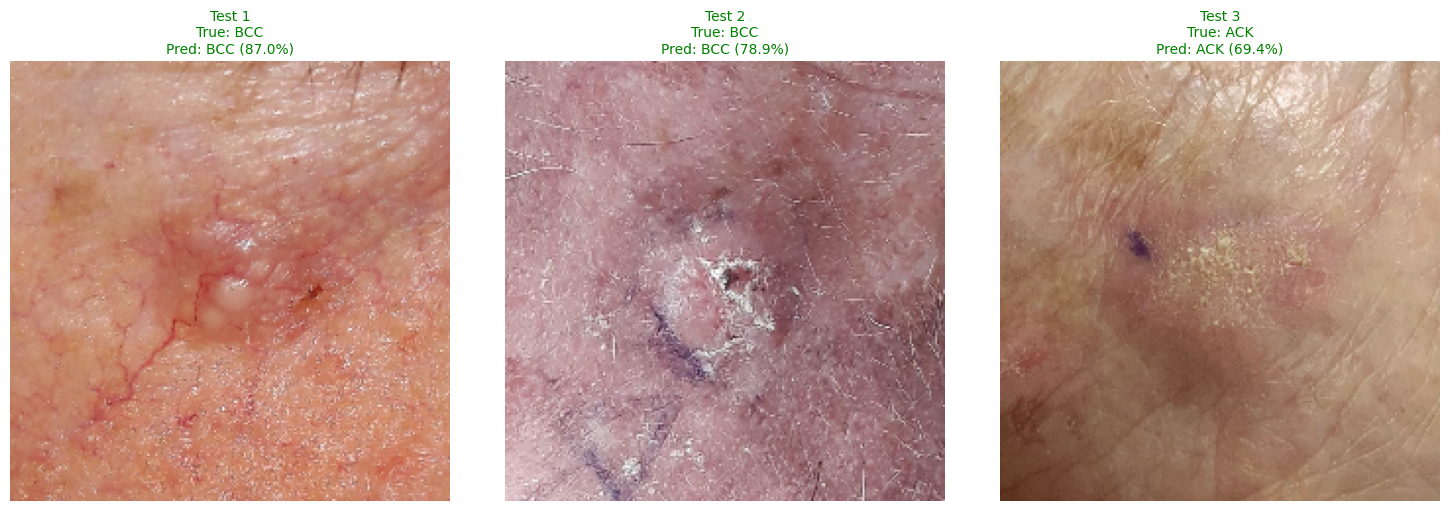

In [15]:
print("TESTING DENSENET201 PREDICTIONS ON SAMPLE IMAGES")
print("=" * 60)

densenet_model.load_weights('best_densenet201_skin_cancer.keras')

class_names = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
class_descriptions = [
    'ACK - Actinic Keratosis (Non-Cancerous)',
    'BCC - Basal Cell Carcinoma (Cancerous)', 
    'MEL - Melanoma (Cancerous)',
    'NEV - Nevus (Non-Cancerous)',
    'SCC - Squamous Cell Carcinoma (Cancerous)',
    'SEK - Seborrheic Keratosis (Non-Cancerous)'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for test_num in range(3):
    sample_idx = np.random.randint(0, len(X_test))
    sample_image_path = X_test.iloc[sample_idx]['image_path']
    true_label = np.argmax(y_test_cat[sample_idx])
    
    print(f"\nTEST SAMPLE {test_num + 1}:")
    print(f"Image: {sample_image_path.split('/')[-1]}")
    print(f"True Label: {class_descriptions[true_label]}")
    
    img = tf.keras.preprocessing.image.load_img(sample_image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = densenet_model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)
    
    is_cancerous_true = true_label in [1, 2, 4]  # BCC, MEL, SCC
    is_cancerous_pred = predicted_class in [1, 2, 4]
    is_correct = predicted_class == true_label
    
    print(f"Predicted: {class_descriptions[predicted_class]}")
    print(f"Confidence: {confidence:.1%}")
    print(f"6-Class Prediction: {'CORRECT' if is_correct else 'INCORRECT'}")
    print(f"Cancer Classification: {'CORRECT' if is_cancerous_true == is_cancerous_pred else 'INCORRECT'}")
    
    print(f"All Class Probabilities:")
    for i, (name, prob) in enumerate(zip(class_names, prediction[0])):
        marker = " <- PREDICTED" if i == predicted_class else ""
        marker += " (TRUE)" if i == true_label else ""
        print(f"  {name}: {prob:.1%}{marker}")
    
    axes[test_num].imshow(img)
    title = f'Test {test_num + 1}\nTrue: {class_names[true_label]}\nPred: {class_names[predicted_class]} ({confidence:.1%})'
    color = 'green' if is_correct else 'red'
    axes[test_num].set_title(title, fontsize=10, color=color)
    axes[test_num].axis('off')

plt.tight_layout()
plt.show()